➡️线性回归的从零开始实现

In [41]:
%matplotlib inline
import torch
import random
import matplotlib.pyplot as plt
# from d2l import torch as d2l

根据带有噪声的线性模型构造一个人造数据集。我们使用线性模型参数w=[2，-3.4].T，b2，和噪声项c生成数据集及其标签

y = Xw+b+c

In [ ]:
def synthetic_data(w, b, num_examples):
    '''生成y = Xw + b + noise'''
    X = torch.normal(0, 1, (num_examples, len(w))) #均值为0，方差为1，张量形状为(num_examples, len(w))
    Y = torch.matmul(X, w)+b #矩阵乘法
    Y += torch.normal(0, 0.01, Y.shape) #加入噪声，均值为0，方差为0.01
    return X, Y.reshape((-1, 1)) #(-1, 1)表示行数不定，列数为1

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, lables = synthetic_data(true_w, true_b, 1000)

features中每一行都包含一个二维数据样本，labels中每一行都包含一维标签值(一个标签值)

In [43]:
print('features:', features[0],'\nlabel:', lables[0])

features: tensor([0.4440, 0.6749]) 
label: tensor([2.7763])


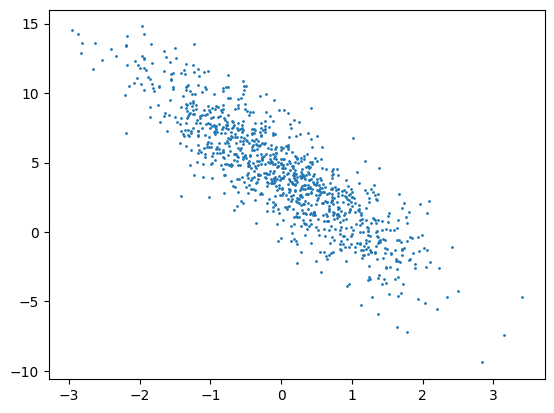

In [44]:
plt.plot()
plt.scatter(features[:, 1].detach().numpy(), lables.detach().numpy(), 1) # .detach():从计算图中分离张量，防止梯度传播。这是 PyTorch 中常用的操作，用于在不需要梯度计算时提高效率。
# plt.scatter()函数用于绘制散点图, 第一个参数为x轴数据，第二个参数为y轴数据，第三个参数为点的大小

设置一个函数来读取小批量

定义一个data_iter函数，该函数接收批量大小、特征矩阵和标签向量作为输入，生成大小为batch_size的小批量

In [45]:
def data_iter(batch_size, features, lables):
    num_examples = len(features)
    indices = list(range(num_examples))
    # 这些样本是随机访问的，没有特定的顺序
    random.shuffle(indices) #随机打乱索引
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i:min(i+batch_size, num_examples)]) #取出batch_size个索引
        yield features[batch_indices], lables[batch_indices] #yield:生成器函数，返回一个迭代器

batch_size = 10

for X, y in data_iter(batch_size, features, lables):
    print(X, '\n', y)
    break

tensor([[ 0.7814, -1.2247],
        [-0.5546,  0.6659],
        [ 0.5017, -1.5304],
        [ 1.3427,  0.3693],
        [-0.3501,  0.1106],
        [ 0.4450, -0.3444],
        [-0.8707, -0.4860],
        [ 0.5292, -0.4072],
        [ 1.6744, -0.6092],
        [-1.0322, -0.9783]]) 
 tensor([[ 9.9473],
        [ 0.8241],
        [10.4053],
        [ 5.6449],
        [ 3.1154],
        [ 6.2424],
        [ 4.1178],
        [ 6.6477],
        [ 9.6049],
        [ 5.4620]])


定义初始化模型

In [46]:
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True) #均值为0，方差为0.01，张量形状为(2, 1)
b = torch.zeros(1, requires_grad=True) 

定义模型

In [47]:
def linreg(X, w, b):
    return torch.matmul(X, w) + b #线性回归模型

定义损失函数

In [48]:
def squared_loss(y_hat, y):
    return (y_hat - y.reshape(y_hat.shape))**2/2 #平方损失函数

定义优化算法

In [49]:
def sgd(params, lr, batch_size):
    with torch.no_grad(): #不计算梯度
        for param in params:
            param -= lr * param.grad / batch_size #梯度下降更新参数
            param.grad.zero_() #梯度清零

训练过程

In [50]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, lables):
        l = loss(net(X, w, b), y) #X和y的小批量损失
        # 因为l形状是(batch_size,1)，而不是一个标量，所以l中所有元素都需要求和，l.sum()是标量
        # 并以此计算w和b的梯度
        l.sum().backward() #反向传播
        sgd([w, b], lr, batch_size) #更新参数
    with torch.no_grad():
        train_l = loss(net(features, w, b), lables)
        print(f'epoch', epoch+1, 'loss', float(train_l.mean()))

epoch 1 loss 0.03986771032214165
epoch 2 loss 0.00015045916370581836
epoch 3 loss 5.370335202314891e-05


比较真实参数和通过训练得到的参数来评估训练的成功程度

In [51]:
print('w的估计误差:', true_w - w.reshape(true_w.shape))
print('b的估计误差:', true_b - b)

w的估计误差: tensor([ 0.0008, -0.0006], grad_fn=<SubBackward0>)
b的估计误差: tensor([0.0005], grad_fn=<RsubBackward1>)


------------------------------------------------------------------------------------------------------------------------------------------------

➡️线性回归的简单实现————调用pytorch中的torch.nn的模块进行搭建

In [52]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils import data

In [53]:
true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, lables = synthetic_data(true_w, true_b, 1000)

调用框架中现有的API来读取数据

In [54]:
def load_array(data_arrays, batch_size, is_train=True):
    "构造一个数据迭代器"
    dataset = data.TensorDataset(*data_arrays) #将数据转换为TensorDataset格式
    return data.DataLoader(dataset, batch_size, shuffle=is_train) #shuffle:是否打乱数据, 每次从中随机抽取batch_size个样本

batch_size = 10
data_iter = load_array((features, lables), batch_size)

next(iter(data_iter)) #取出一个batch的数据

[tensor([[-1.1541e+00,  6.5186e-01],
         [-3.6817e-01,  1.8725e+00],
         [-2.1504e-01, -1.3078e-01],
         [ 3.5093e+00,  2.9480e-01],
         [ 1.7258e+00, -3.1482e-01],
         [ 1.0830e+00,  6.8527e-01],
         [-1.0325e+00, -1.7073e-03],
         [ 8.0306e-01,  2.7319e-01],
         [-3.4517e-02,  7.9939e-01],
         [-1.3169e+00, -1.1216e+00]]),
 tensor([[-0.3253],
         [-2.9048],
         [ 4.2388],
         [10.2235],
         [ 8.7334],
         [ 4.0363],
         [ 2.1533],
         [ 4.8703],
         [ 1.4168],
         [ 5.3856]])]

使用框架定义好的层定义模型

In [55]:
net = nn.Sequential(nn.Linear(2, 1)) #线性回归模型，输入2维，输出1维，sequential:顺序容器

初始化模型参数

In [56]:
net[0].weight.data.normal_(0, 0.01) #使用normal来替换data的值均值为0，方差为0.01，net[0]:第一个线性层
net[0].bias.data.fill_(0) #偏置初始化为0

tensor([0.])

计算均方误差使用的是Mseloss类，也称L2范数

In [57]:
loss = nn.MSELoss() #均方误差损失函数

实例化SDG算法

In [58]:
trainer = torch.optim.SGD(net.parameters(), lr=0.03) #SGD优化器,传入模型参数

In [ ]:
num_epoch = 3

for epoch in range(num_epoch):
    for X, y in data_iter:
        trainer.zero_grad()
        l = loss(net(X), y)
        l.backward() #pyTorch会自动求和
        trainer.step() #更新参数
    l = loss(net(features), lables)
    print(f'epoch {epoch + 1}, loss {l:f}')


epoch 1, loss 0.000302
epoch 2, loss 0.000096
epoch 3, loss 0.000096
